In [1]:
import sys
import pathlib
import random

import matplotlib.pyplot as plt

# Locate the repository root (the directory that contains simulation_engine) so the
# notebook runs regardless of the directory Jupyter was launched from.
repository_path = pathlib.Path.cwd()
while not (repository_path / "simulation_engine").is_dir() and repository_path != repository_path.parent:
    repository_path = repository_path.parent
machine_learning_path = repository_path / "notebooks" / "machine_learning"
for path_entry in (str(repository_path), str(machine_learning_path)):
    if path_entry not in sys.path:
        sys.path.insert(0, path_entry)

import simulation_engine as engine
import simulation_engine.rl as rl
import simulation_engine.initialization as initialization
import simulation_engine.models as models
import rl_helpers.rl_plots as rl_plots

%matplotlib inline
%load_ext autoreload
%autoreload 2

# 1 - The environment and its Markov decision process

This notebook frames *Volcano Rush* as a reinforcement learning problem. It introduces the
engine, identifies the two decisions our agent will learn, shows the engine hook that lets a
learned policy replace the rule-based one without changing default behaviour, and lays out the
semi-Markov decision process the later notebooks train against.

*Volcano Rush* is a cooperative survival board game for 6-8 players stranded on a volcanic
island. Each player holds a hand of resource cards (wood, stone, rope). Every round one *active
player* leads a *mission* drawn from three currently on offer; a set of participants pays the
mission's per-player cost, a complication card may raise that cost, and on success the team gains
points and sometimes a boat part. After most rounds a card is turned from the volcano deck. The
team **wins** by building all required boat parts (3 at 6 players, 4 at 7, 5 at 8) and **loses**
if the Eruption card appears first.

## The three per-round decisions

Each round the engine makes three decisions through `simulation_engine/agents/`:

1. **Shuffle or play** (`decide_mission_action`) - a narrow rule we leave fixed.
2. **Which mission to attempt** (`vote_for_mission`) - the active player picks one of the three
   active missions. **We learn this.**
3. **Who participates** (`active_player_select_participants`) - the active player staffs the
   mission. **We learn this too.**

Let us look at a freshly initialised game.

In [2]:
random.seed(7)
state = initialization.init_game(player_count = 7)
print('Characters at the camp:', [player.character.value for player in state.players])
print('Three active missions:', [mission.value for mission in state.active_missions])
print('Boat parts required:', state.boat_parts_required)
print('Volcano cards in deck:', len(state.volcano_deck))

Characters at the camp: ['sailor', 'builder', 'gatherer', 'cook', 'fire_starter', 'craftsman', 'fire_starter']
Three active missions: ['raise_the_mast', 'torch_for_the_night', 'cut_the_keel']
Boat parts required: 4
Volcano cards in deck: 11


## Injecting a learned policy: the engine hook

`run_game` and `run_scenario` accept two optional callables, `mission_selector` and
`participant_selector`. When they are `None` the engine calls the original rule-based functions,
so the default game is **bit-identical** to before - existing simulations and notebooks are
unaffected. A learned agent simply supplies a different callable.

Below we confirm two things: the default path is unchanged, and a trivial custom selector (always
take the first legal mission) really does change outcomes - proving the hook is wired in.

In [3]:
def always_first_legal_mission(active_player, state):
    legal = rl.legal_missions(active_player, state)
    return legal[0] if legal else None

baseline_records = engine.run_scenario(player_count = 7, n_games = 400, base_seed = 42)
custom_records = engine.run_scenario(
    player_count = 7, n_games = 400, base_seed = 42,
    mission_selector = always_first_legal_mission,
)

baseline_wins = sum(1 for record in baseline_records if record.outcome == models.GameOutcome.WIN)
custom_wins = sum(1 for record in custom_records if record.outcome == models.GameOutcome.WIN)
print(f'rule-based baseline wins:        {baseline_wins} / 400')
print(f'first-legal-mission policy wins: {custom_wins} / 400')
print('The baseline is a strong heuristic; a naive selector plays noticeably worse.')

rule-based baseline wins:        139 / 400
first-legal-mission policy wins: 89 / 400
The baseline is a strong heuristic; a naive selector plays noticeably worse.


## The decision process

We model the team's play as a finite-horizon Markov decision process (MDP). A state $s$ summarises
the situation, an action $a$ is a decision, the environment returns a reward $r$ and a next state
$s'$, and the agent seeks a policy $\pi$ maximising the expected discounted return
$G_t = \sum_{k\ge 0} \gamma^k r_{t+k}$ with discount $0 < \gamma \le 1$.

Two complications make this a **semi-MDP** rather than a plain MDP:

- The agent only acts on some rounds. Shuffle and forfeit rounds advance the game (and the volcano
  deck) with no agent action. A learned decision therefore transitions to the *next decision of the
  same kind*, accumulating any reward earned over the skipped rounds.
- There are two decision streams (mission and participant). We treat them as two parallel
  semi-MDPs that share one reward stream but each keep their own value table, so neither bootstraps
  on the other's estimates.

Notebook 2 designs the state and action abstractions; notebook 3 trains them. As a teaser, here is a
short training run - even a few thousand games of self-play visibly shift the win rate as
exploration decays.

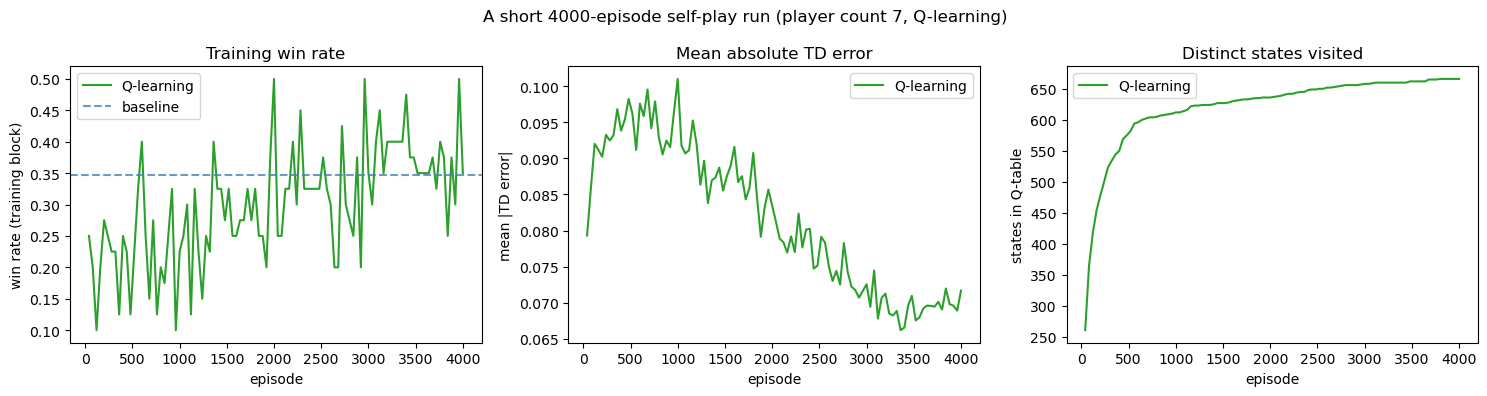

In [4]:
teaser_config = rl.TrainingConfig(
    player_count = 7,
    n_episodes = 4000,
    base_seed = 1000,
    schedules = rl.Schedules(epsilon_decay_episodes = 3000),
    exploration_seed = 7,
)
teaser_result = rl.train_self_play(teaser_config)

teaser_curves = {
    teaser_config.update_rule.value: {
        'checkpoint_episodes': teaser_result.checkpoint_episodes,
        'win_rate_curve': teaser_result.win_rate_curve,
        'td_error_curve': teaser_result.td_error_curve,
        'mission_states_curve': teaser_result.mission_states_curve,
        'participant_states_curve': teaser_result.participant_states_curve,
    }
}
figure = rl_plots.plot_training_curves(
    teaser_curves,
    baseline_win_rate = baseline_wins / 400,
    title = 'A short 4000-episode self-play run (player count 7, Q-learning)',
)
plt.show()

## Where this goes next

- **Notebook 2** designs the compact state abstractions and the action spaces, and measures how few
  states actually occur in play.
- **Notebook 3** trains Q-learning and SARSA agents and inspects convergence.
- **Notebook 4** evaluates the learned policies against the baseline with paired statistics.
- **Notebook 5** opens the Q-tables to see what the agents learned.